In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

from probabilisticnn.pnn import PNN, AdaptivePNN
from probabilisticnn.grnn import GRNN, AdaptiveGRNN


N_REPEATS = 2000
N_FEATURES = 20

FIXED_N_TRAIN = 1000
FIXED_N_TEST = 1000

N_TEST_GRID = [100, 250, 500, 1000, 2000]
N_TRAIN_GRID = [100, 250, 500, 1000, 2000]

MODEL_SPECS = [
    ("pnn", None),
    ("adaptive_pnn", "per_feature"),
    ("adaptive_pnn", "per_class"),
    ("adaptive_pnn", "per_class_per_feature"),
    ("grnn", None),
    ("adaptive_grnn", None),
]

AVAILABLE_BACKENDS = ["numpy", "numba"]
import probabilisticnn.numba_backend


In [ ]:
def get_dataset(
    n_train=1000,
    n_test=1000,
    n_features=N_FEATURES,
    task="classification",
    seed=42,
    dtype=np.dtype("float64"),
):
    rng = np.random.default_rng(seed)
    X_train = rng.random((n_train, n_features), dtype=dtype)
    X_test = rng.random((n_test, n_features), dtype=dtype)

    if task == "classification":
        y = rng.integers(0, 3, size=n_train)
    elif task == "regression":
        y = (
            np.sin(2.0 * X_train[:, 0])
            + 0.25 * X_train[:, min(1, n_features - 1)]
            + 0.05 * rng.normal(size=n_train)
        ).astype(dtype, copy=False)
    else:
        raise ValueError(f"Unknown task: {task}")

    return X_train, X_test, y


def resolve_model(model_name, bandwidth_sharing=None, backend="numpy"):
    if model_name == "pnn":
        return PNN(bandwidth=0.8, normalize=False, backend=backend, compute_dtype="float64")
    elif model_name == "grnn":
        return GRNN(bandwidth=1.0, backend=backend, compute_dtype="float64")
    elif model_name == "adaptive_grnn":
        return AdaptiveGRNN(max_iter=20, normalize=False, backend=backend, compute_dtype="float64")
    elif model_name == "adaptive_pnn":
        return AdaptivePNN(
            bandwidth_sharing=bandwidth_sharing,
            max_iter=20,
            normalize=False,
            backend=backend,
            compute_dtype="float64",
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")


def get_model_label(model_name, bandwidth_sharing=None):
    if model_name == "pnn":
        return "PNN"
    if model_name == "grnn":
        return "GRNN"
    if model_name == "adaptive_grnn":
        return "AdaptiveGRNN"
    if model_name == "adaptive_pnn":
        return f"AdaptivePNN [{bandwidth_sharing}]"
    raise ValueError(f"Unknown model: {model_name}")


def measure_inference(model, X):
    start = perf_counter()
    model.predict(X)
    end = perf_counter()
    return end - start


def collect_stats(model, X, sample_size=N_REPEATS):
    model.predict(X)
    sample = []

    for _ in range(sample_size):
        seconds = measure_inference(model, X)
        sample.append(seconds)

    sample = np.asarray(sample, dtype=np.float64)
    return np.mean(sample), np.std(sample, ddof=1)


def run_benchmark(grid, *, fixed_n_train=None, fixed_n_test=None, x_key="n_test"):
    rows = []

    for model_name, bandwidth_sharing in MODEL_SPECS:
        label = get_model_label(model_name, bandwidth_sharing)
        task = "classification" if "pnn" in model_name else "regression"

        for backend in AVAILABLE_BACKENDS:
            xs = []
            means = []
            stds = []

            for i, value in enumerate(grid):
                n_train = fixed_n_train if fixed_n_train is not None else value
                n_test = fixed_n_test if fixed_n_test is not None else value

                model = resolve_model(model_name, bandwidth_sharing, backend)
                X_train, X_test, y = get_dataset(
                    n_train=n_train,
                    n_test=n_test,
                    task=task,
                    seed=42 + i,
                )
                model.fit(X_train, y)
                mean, std = collect_stats(model, X_test, sample_size=N_REPEATS)

                xs.append(value)
                means.append(mean)
                stds.append(std)

                rows.append(
                    {
                        "model": model_name,
                        "bandwidth_sharing": bandwidth_sharing or "fixed",
                        "label": label,
                        "backend": backend,
                        "n_train": n_train,
                        "n_test": n_test,
                        x_key: value,
                        "mean": mean,
                        "std": std,
                        "mean_se": std / np.sqrt(N_REPEATS),
                    }
                )
    return rows


def plot_backend_comparison(rows, *, x_key, title_suffix):
    labels = []
    for model_name, bandwidth_sharing in MODEL_SPECS:
        labels.append(get_model_label(model_name, bandwidth_sharing))

    for label in labels:
        plt.figure(figsize=(10, 5))
        for backend in AVAILABLE_BACKENDS:
            part = [row for row in rows if row["label"] == label and row["backend"] == backend]
            part = sorted(part, key=lambda row: row[x_key])
            x = [row[x_key] for row in part]
            mean = np.array([row["mean"] for row in part]) * 1000
            mean_se = np.array([row["mean_se"] for row in part]) * 1000
            plt.errorbar(x, mean, yerr=mean_se, marker="o", capsize=3, label=backend)

        plt.title(f"{label}: {title_suffix}")
        plt.xlabel(x_key)
        plt.ylabel("predict latency [ms]")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


def benchmark_results_to_dataframe(rows, *, size_key):
    table = {}

    for row in rows:
        index = (row["model"], row["bandwidth_sharing"], row[size_key])
        if index not in table:
            table[index] = {}

        table[index][f"{row['backend']}_mean"] = row["mean"]
        table[index][f"{row['backend']}_mean_se"] = row["mean_se"]

    df = pd.DataFrame.from_dict(table, orient="index")
    df.index = pd.MultiIndex.from_tuples(df.index, names=["model", "bandwidth_sharing", size_key])
    return df.sort_index()


/Users/g.vinogradov/Documents/Personal/ProbabilisticNN/.venv/lib/python3.14/site-packages/probabilisticnn/pnn/pnn.py:195: RuntimeWarning: Optimization did not converge. Reason: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  ).optimize()
/Users/g.vinogradov/Documents/Personal/ProbabilisticNN/.venv/lib/python3.14/site-packages/probabilisticnn/pnn/pnn.py:195: RuntimeWarning: Optimization did not converge. Reason: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  ).optimize()
/Users/g.vinogradov/Documents/Personal/ProbabilisticNN/.venv/lib/python3.14/site-packages/probabilisticnn/pnn/pnn.py:195: RuntimeWarning: Optimization did not converge. Reason: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  ).optimize()
/Users/g.vinogradov/Documents/Personal/ProbabilisticNN/.venv/lib/python3.14/site-packages/probabilisticnn/pnn/pnn.py:195: RuntimeWarning: Optimization did not converge. Reason: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  ).optimize()
/Users/g.vinogradov/Documents/Personal/ProbabilisticNN/.

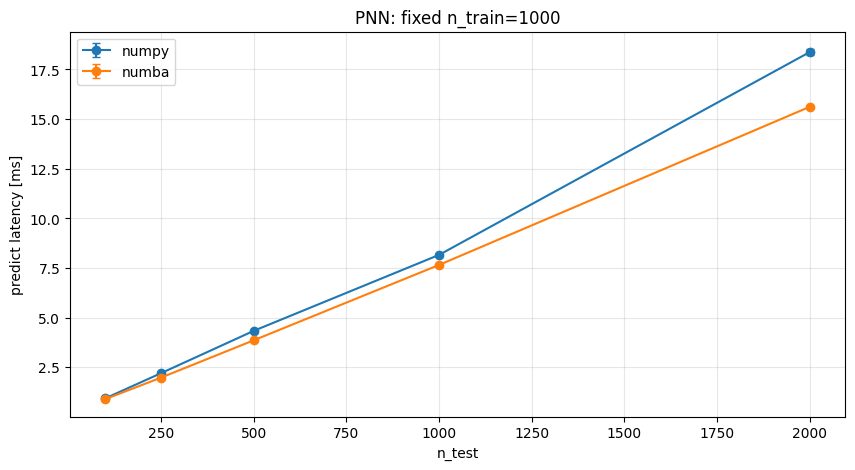

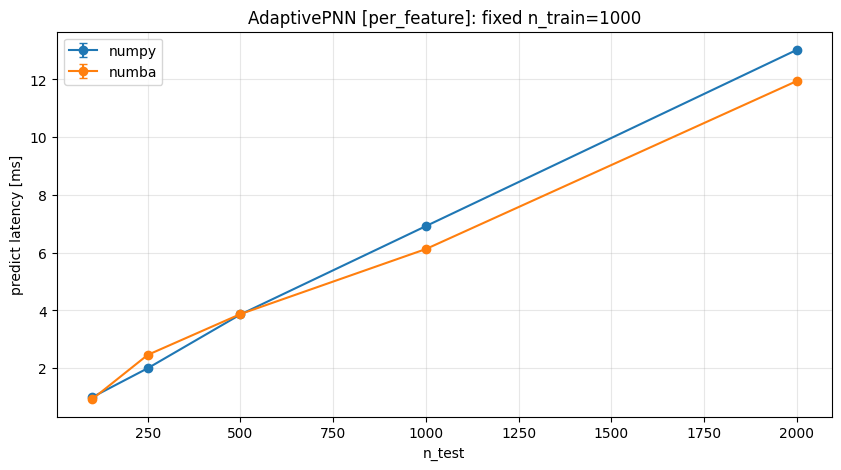

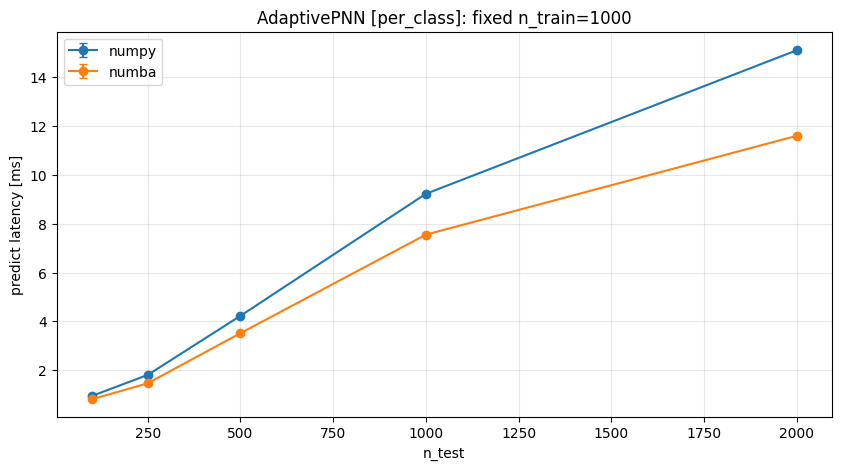

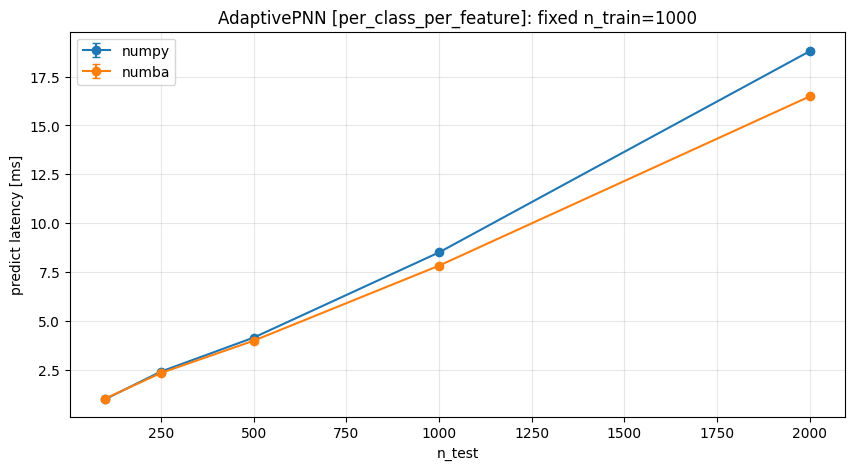

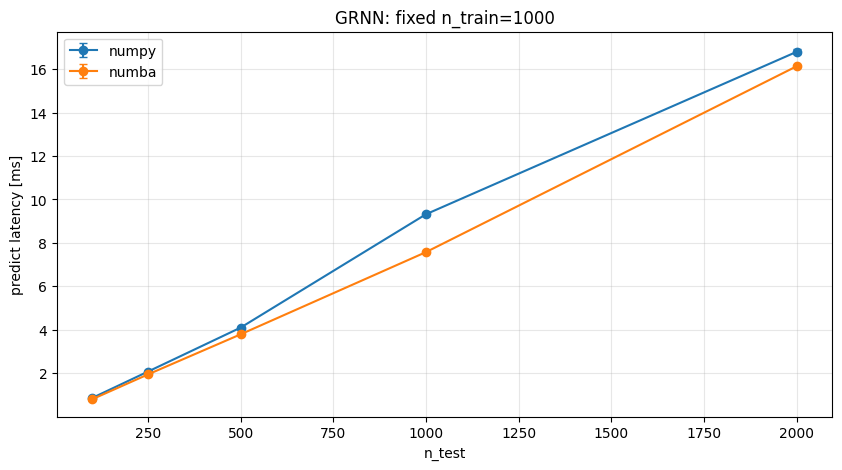

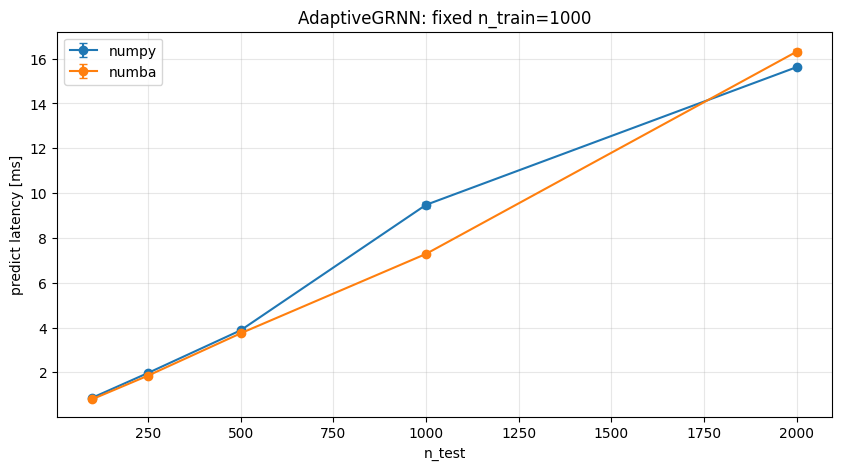

numpy_mean  numpy_mean_se  \
model         bandwidth_sharing     n_test                              
adaptive_grnn fixed                 100       0.000869   6.023179e-07   
                                    250       0.001971   1.062515e-06   
                                    500       0.003876   1.004185e-06   
                                    1000      0.009474   1.322516e-04   
                                    2000      0.015621   3.437072e-05   
adaptive_pnn  per_class             100       0.000949   1.551521e-06   
                                    250       0.001807   2.307887e-06   
                                    500       0.004227   1.347990e-05   
                                    1000      0.009225   5.334110e-05   
                                    2000      0.015103   4.452011e-05   
              per_class_per_feature 100       0.001001   1.998494e-06   
                                    250       0.002411   2.658312e-06   
                                    500       0.004148   1.653860e-05   
                                    1000      0.008506   2.725462e-05   
                                    2000      0.018797   1.001085e-04   
              per_feature           100       0.000996   1.226750e-06   
                                    250       0.002001   2.041778e-05   
                                    500       0.003862   3.071379e-06   
                                    1000      0.006921   4.395536e-05   
                                    2000      0.013022   2.385968e-05   
grnn          fixed                 100       0.000868   1.176334e-06   
                                    250       0.002078   1.522884e-05   
                                    500       0.004102   1.160720e-05   
                                    1000      0.009319   6.170712e-05   
                                    2000      0.016795   1.169198e-04   
pnn           fixed                 100       0.000935   4.183848e-06   
                                    250       0.002202   1.838300e-05   
                                    500       0.004334   2.645603e-05   
                                    1000      0.008160   1.455884e-05   
                                    2000      0.018377   1.422439e-04   

                                            numba_mean  numba_mean_se  
model         bandwidth_sharing     n_test                             
adaptive_grnn fixed                 100       0.000804   1.593296e-06  
                                    250       0.001852   6.707518e-07  
                                    500       0.003742   1.892120e-05  
                                    1000      0.007285   4.933780e-06  
                                    2000      0.016312   1.050434e-04  
adaptive_pnn  per_class             100       0.000812   1.242335e-06  
                                    250       0.001464   1.428004e-06  
                                    500       0.003517   4.707645e-06  
                                    1000      0.007552   3.260030e-05  
                                    2000      0.011600   2.165236e-05  
              per_class_per_feature 100       0.001034   2.920776e-05  
                                    250       0.002339   2.225480e-06  
                                    500       0.003989   1.370262e-05  
                                    1000      0.007828   3.156672e-05  
                                    2000      0.016487   3.888808e-05  
              per_feature           100       0.000928   4.119281e-07  
                                    250       0.002463   5.139910e-05  
                                    500       0.003876   1.526411e-05  
                                    1000      0.006127   3.742634e-05  
                                    2000      0.011942   2.322280e-05  
grnn          fixed                 100       0.000808   2.943987e-07  
                                    250       0.001

In [ ]:
results_n_test = run_benchmark(
    N_TEST_GRID,
    fixed_n_train=FIXED_N_TRAIN,
    x_key="n_test",
)

plot_backend_comparison(
    results_n_test,
    x_key="n_test",
    title_suffix=f"fixed n_train={FIXED_N_TRAIN}",
)

df_n_test = benchmark_results_to_dataframe(results_n_test, size_key="n_test")
df_n_test

In [7]:
df_n_test.to_markdown(floatfmt=".2f")

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

In [8]:
!pip install tabulate

  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [10]:
print(df_n_test.to_markdown(floatfmt=".2f"))

|                                                 |   numpy_mean |   numpy_mean_se |   numba_mean |   numba_mean_se |
|:------------------------------------------------|-------------:|----------------:|-------------:|----------------:|
| ('adaptive_grnn', 'fixed', 100)                 |         0.00 |            0.00 |         0.00 |            0.00 |
| ('adaptive_grnn', 'fixed', 250)                 |         0.00 |            0.00 |         0.00 |            0.00 |
| ('adaptive_grnn', 'fixed', 500)                 |         0.00 |            0.00 |         0.00 |            0.00 |
| ('adaptive_grnn', 'fixed', 1000)                |         0.01 |            0.00 |         0.01 |            0.00 |
| ('adaptive_grnn', 'fixed', 2000)                |         0.02 |            0.00 |         0.02 |            0.00 |
| ('adaptive_pnn', 'per_class', 100)              |         0.00 |            0.00 |         0.00 |            0.00 |
| ('adaptive_pnn', 'per_class', 250)              |     